In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import RobustScaler
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/btc_1h_data_2018_to_2025.csv"
df = pd.read_csv(file_path)
df.head(3)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999000,5.993910e+06,5228,228.521921,3.090541e+06,0
1,2018-01-01 01:00:00.000000,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999000,5.154522e+06,4534,180.840403,2.430449e+06,0
2,2018-01-01 02:00:00.000000,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999000,5.710192e+06,4887,192.237935,2.558505e+06,0


In [ ]:
df.tail(3)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
71780,2026-03-15 20:00:00.000000,71549.94,71930.00,71433.75,71730.81,236.54566,2026-03-15 20:59:59.999000,1.696668e+07,76529,138.53196,9.935537e+06,0
71781,2026-03-15 21:00:00.000000,71730.81,72222.00,71629.99,72109.58,459.80342,2026-03-15 21:59:59.999000,3.309877e+07,136792,297.88651,2.144302e+07,0
71782,NaN,72109.59,73081.77,71725.74,72749.44,1471.44945,NaN,1.065980e+08,312854,860.63713,6.236168e+07,0


In [ ]:
#Drop Junk columns
columns_to_drop =['Close time','Ignore']
df.drop(columns=columns_to_drop,axis=1,inplace=True)
#Replace spaces and convert tow lowercase
df.columns = df.columns.str.replace(' ','_').str.lower()
print(df.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume',
       'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume',
       'taker_buy_quote_asset_volume'],
      dtype='object')


In [ ]:
#Types Conversions
#datetime conversion
df['open_time']=pd.to_datetime(df['open_time'])
#numeric flaot columns
float_cols = ['open','high','low','close','volume','quote_asset_volume',
              'taker_buy_base_asset_volume',
              'taker_buy_quote_asset_volume']
df[float_cols]=df[float_cols].astype(float)
#integer column
df['number_of_trades']=df['number_of_trades'].astype(int)

#EDA Analaysis

##duplicated rows and nan values

In [ ]:
#check all missing values
print("Check count of Nan values on each row ")
df.isna().sum()

Check count of Nan values on each row 


,0
open_time,1
open,0
high,0
low,0
close,0
volume,0
quote_asset_volume,0
number_of_trades,0
taker_buy_base_asset_volume,0
taker_buy_quote_asset_volume,0


In [ ]:
#correct missin value on open time column
df.loc[df['open_time'].isna(), 'open_time'] = pd.Timestamp('2026-03-15 22:00:00')
df.tail(2)

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
71781,2026-03-15 21:00:00,71730.81,72222.00,71629.99,72109.58,459.80342,3.309877e+07,136792,297.88651,2.144302e+07
71782,2026-03-15 22:00:00,72109.59,73081.77,71725.74,72749.44,1471.44945,1.065980e+08,312854,860.63713,6.236168e+07


In [ ]:
print(f"Numbers of rows before check duplication:{len(df)}")
print(f"Number of duplicated rows {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Numbers of colums after Removing duplicaating:{len(df)}")

Numbers of rows before check duplication:71783
Number of duplicated rows 0
Numbers of colums after Removing duplicaating:71783


##Detecting Gaps :


###Check missing intervals

In [ ]:
#convert open_time to Datetime object
df['open_time'] = pd.to_datetime(df['open_time'],errors='coerce')
#set open_time column as index
df.set_index('open_time',inplace=True)
#ensure that data is sorted
df.sort_index(inplace=True)
#detect missing intervals
time_diffs = df.index.to_series().diff()
expected_gap = pd.Timedelta("1H")
gaps = time_diffs[time_diffs>expected_gap].iloc[1:]
if gaps.empty:
  print("no gaps")
else:
  print(f"Gaps detected : {len(gaps)}")
  print(gaps)


Gaps detected : 26
open_time
2018-02-09 10:00:00   1 days 10:00:00
2018-06-26 12:00:00   0 days 11:00:00
2018-06-27 14:00:00   0 days 02:00:00
2018-07-04 08:00:00   0 days 08:00:00
2018-10-19 09:00:00   0 days 04:00:00
2018-11-14 09:00:00   0 days 08:00:00
2019-03-12 08:00:00   0 days 07:00:00
2019-05-15 13:00:00   0 days 11:00:00
2019-08-15 10:00:00   0 days 09:00:00
2019-11-13 04:00:00   0 days 03:00:00
2019-11-25 04:00:00   0 days 03:00:00
2020-02-09 03:00:00   0 days 02:00:00
2020-02-19 17:00:00   0 days 06:00:00
2020-03-04 11:00:00   0 days 02:00:00
2020-04-25 04:00:00   0 days 03:00:00
2020-06-28 05:00:00   0 days 04:00:00
2020-11-30 07:00:00   0 days 02:00:00
2020-12-21 18:00:00   0 days 05:00:00
2020-12-25 03:00:00   0 days 02:00:00
2021-02-11 05:00:00   0 days 02:00:00
2021-03-06 03:00:00   0 days 02:00:00
2021-04-20 04:00:00   0 days 03:00:00
2021-04-25 08:00:00   0 days 04:00:00
2021-08-13 06:00:00   0 days 05:00:00
2021-09-29 09:00:00   0 days 03:00:00
2023-03-24 14:00:00  

/tmp/ipykernel_2344/88880884.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  expected_gap = pd.Timedelta("1H")


###Reindex and Forward Fill

In [ ]:
#check and revmove duplicate timestamp
print(f"Numbers of rows before check duplication:{len(df)}")
duplicates = df.index.duplicated().sum()
print(f"Number of duplicate timestamps: {duplicates}")
# If you want to see exactly which ones they are:
print(df[df.index.duplicated(keep=False)])
# keep='first' ensures we keep the first instance and drop subsequent ones
df = df[~df.index.duplicated(keep='last')]
print(f"Numbers of colums after Removing duplicaating:{len(df)}")

Numbers of rows before check duplication:71783
Number of duplicate timestamps: 2
                          open       high        low      close      volume  \
open_time                                                                     
2018-07-07 00:00:00  107469.22  107813.04  107440.63  107692.01  228.631950   
2018-07-07 00:00:00    6609.79    6613.99    6581.05    6596.93  766.671591   
2018-07-07 01:00:00  107692.01  107941.99  107689.91  107911.20  255.841360   
2018-07-07 01:00:00    6596.93    6600.00    6561.01    6566.01  887.436249   

                     quote_asset_volume  number_of_trades  \
open_time                                                   
2018-07-07 00:00:00        2.461733e+07             42593   
2018-07-07 00:00:00        5.055038e+06              6145   
2018-07-07 01:00:00        2.757870e+07             33521   
2018-07-07 01:00:00        5.837711e+06              6193   

                     taker_buy_base_asset_volume  taker_buy_quote_asset_volum

In [ ]:
print(f"Number of rows before Reindexing : {len(df)}")
perfect_index = pd.date_range(start=df.index.min(), end=df.index.max(),freq='1H')
df = df.reindex(perfect_index)
#forward fil , takes last known price and volumns
df = df.ffill()
#check if we still have gaps
time_diffs = df.index.to_series().diff()
expected_gap = pd.Timedelta("1H")
gaps = time_diffs[time_diffs>expected_gap].iloc[1:]
if gaps.empty:
  print("no gaps")
else :
  print(f"Gaps detected : {len(gaps)}")
  print(gaps)

print(f"Number of rows after Reindexing : {len(df)}")

Number of rows before Reindexing : 71781
no gaps
Number of rows after Reindexing : 71903


/tmp/ipykernel_2344/3803200374.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  perfect_index = pd.date_range(start=df.index.min(), end=df.index.max(),freq='1H')
/tmp/ipykernel_2344/3803200374.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  expected_gap = pd.Timedelta("1H")


In [ ]:
df.tail(5)

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
2026-03-15 18:00:00,71819.96,71885.55,71321.87,71390.53,321.10675,2.300472e+07,102918.0,132.32941,9.482116e+06
2026-03-15 19:00:00,71390.53,71582.83,71338.67,71549.94,251.59972,1.797921e+07,69282.0,123.97206,8.859526e+06
2026-03-15 20:00:00,71549.94,71930.00,71433.75,71730.81,236.54566,1.696668e+07,76529.0,138.53196,9.935537e+06
2026-03-15 21:00:00,71730.81,72222.00,71629.99,72109.58,459.80342,3.309877e+07,136792.0,297.88651,2.144302e+07
2026-03-15 22:00:00,72109.59,73081.77,71725.74,72749.44,1471.44945,1.065980e+08,312854.0,860.63713,6.236168e+07


##Price & Volatility Analysis

1-bell curves VS fat tails  
2- Box plot : we use Robust scaler  
3- Log transformation  
4-

1. What is "Return" and Why use it?

Return is just a fancy word for Percentage Change.

    If Price goes from $100 to $110, the Return is 10% (or 0.10).

The "Magnitude" Problem:
Imagine Bitcoin in two different years:

    2018: Price is $5,000. A $500 move is a 10% jump. (Huge!)

    2024: Price is $60,000. A $500 move is a 0.8% wiggle. (Tiny!)

If you feed the Raw Price into XGBoost, the model sees "500" in both cases. It will think both moves are equally important. By using Returns, the model sees "10%" vs "0.8%". This tells the model that the 2018 move was a massive event, while the 2024 move was just noise.

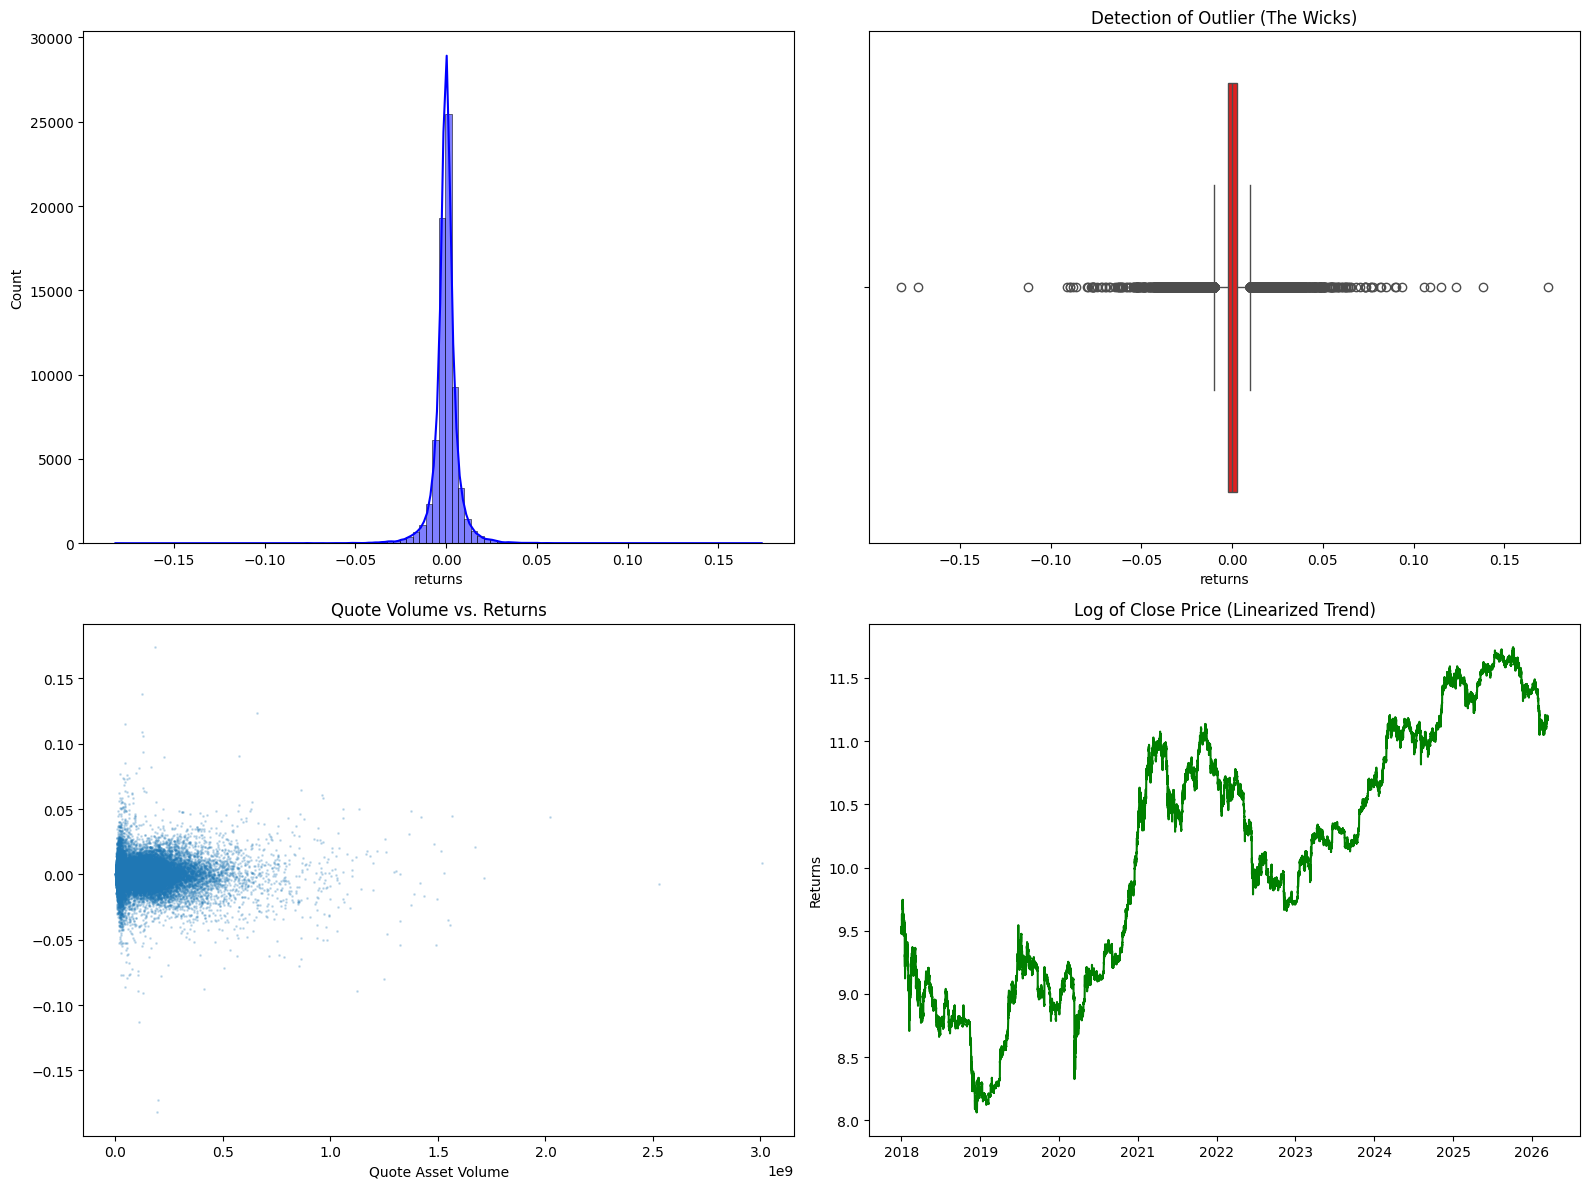

Total Rows: 71903
Extreme Outliers Detected: 6926
Percentage of Extreme Moves: 9.63%


In [ ]:
# We calculate 'returns' because price is too big for the model to compare across years.
# pct_change() calculates: (Current_Price - Previous_Price) / Previous_Price
df['returns'] = df['close'].pct_change()
fig,axes = plt.subplots(2,2,figsize=(16,12))

#to see if price moves are normal or wild
sns.histplot(df['returns'].dropna(),bins=100,kde=True,ax=axes[0,0],color='b')

#outlier check with boxplot
sns.boxplot(x=df['returns'],ax=axes[0,1],color='red')
axes[0,1].set_title("Detection of Outlier (The Wicks)")


# Goal: Does high Quote Volume cause big price moves?
axes[1, 0].scatter(df['quote_asset_volume'], df['returns'], alpha=0.2, s=1)
axes[1, 0].set_title('Quote Volume vs. Returns')
axes[1, 0].set_xlabel('Quote Asset Volume')
axes[1, 1].set_ylabel('Returns')

# Goal: See the percentage growth over time instead of just dollar amounts
axes[1, 1].plot(np.log(df['close']), color='green')
axes[1, 1].set_title('Log of Close Price (Linearized Trend)')

plt.tight_layout()
plt.show()

#statistical summary
q1 = df['returns'].quantile(0.25)
q3 = df['returns'].quantile(0.75)
iqr = q3-q1
outlier_threshold = 1.5*iqr
num_outliers = ((df['returns'] < (q1 - outlier_threshold)) | (df['returns'] > (q3 + outlier_threshold))).sum()
print(f"Total Rows: {len(df)}")
print(f"Extreme Outliers Detected: {num_outliers}")
print(f"Percentage of Extreme Moves: {(num_outliers/len(df))*100:.2f}%")

1. Hourly Returns Distribution (Histogram)

    The Insight: The chart shows a Leptokurtic Distribution (a very high center peak with "Fat Tails"). While most hourly moves are near 0%, the "tails" extending to the edges prove that significant price swings (5-10%+) occur much more frequently than in traditional stock markets.

    Technical Takeaway: Because the data does not follow a "Normal Bell Curve," we must use Robust Scaling (scaling based on medians) rather than Standard Scaling to ensure the model isn't blinded by volatility.

2. Detection of Outliers (Boxplot)

    The Insight: The central red box represents the "Normal" market range (the middle 50% of trades), while the dense trail of black dots represents Extreme Volatility. By fixing previous duplicate errors, the "box" is now visible and mathematically sound.

    Technical Takeaway: Approximately 9.6% of the data is classified as statistical outliers. We will keep these outliers rather than deleting them, as they represent the high-profit "momentum" moments the XGBoost model needs to capture.

3. Quote Volume vs. Returns (Scatter Plot)

    The Insight: This chart reveals a "Megaphone" or "V-Shape" pattern, showing a clear correlation between liquidity and price movement. Large price changes (top and bottom of the Y-axis) only occur when Quote Asset Volume (the X-axis) is high.

    Technical Takeaway: High volume acts as "fuel" for price conviction. This confirms that quote_asset_volume is a high-value feature that will help the model distinguish between "fake" price wiggles and "real" trend breakouts.

4. Log of Close Price (Linearized Trend)

    The Insight: By applying a Logarithmic Transformation, we've converted exponential price growth into a linear trend. This removes the "Scale Bias" where a $1,000 move in 2018 looks different than a $1,000 move in 2026.

    Technical Takeaway: The "Ghost Spikes" (data glitches) have been removed, leaving a continuous, clean price history. This ensures the model can learn from the relative percentage growth across the entire 8-year dataset equally.

##Actions for phase 2
1- Robust Scaling (The "Volatility Buffer") :
Because your Histogram and Boxplot showed "Fat Tails" and 9.6% outliers, you cannot use standard scaling ($Mean$ and $Standard$ $Deviation$).Why: A standard scaler is easily "pulled" by those black dots in your boxplot.

2- Since your Log Price chart showed that Bitcoin has grown exponentially (from 2018 to 2026), the dollar-value difference is huge.

    Why: A $1,000 move in 2018 is not the same as a $1,000 move today.

    The Action: We should use Log Returns or Log Volume. This turns "Multiplication" into "Addition" for the model, making it much easier for the trees in XGBoost to find patterns that work across the whole 8-year history.

3- Handling the "Wicks" (Clipping)

Even though we fixed the 1,600% glitch, your boxplot still shows some very extreme dots (15%+ moves).

    The Decision: Do you want the model to try and predict these "Black Swan" events, or do you want it to focus on "Normal" profitable trading?

    The Action: Most professional traders Clip (Winsorize) the returns at a reasonable limit (like +/- 15%). This prevents a single crazy hour from "overfitting" the model.


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


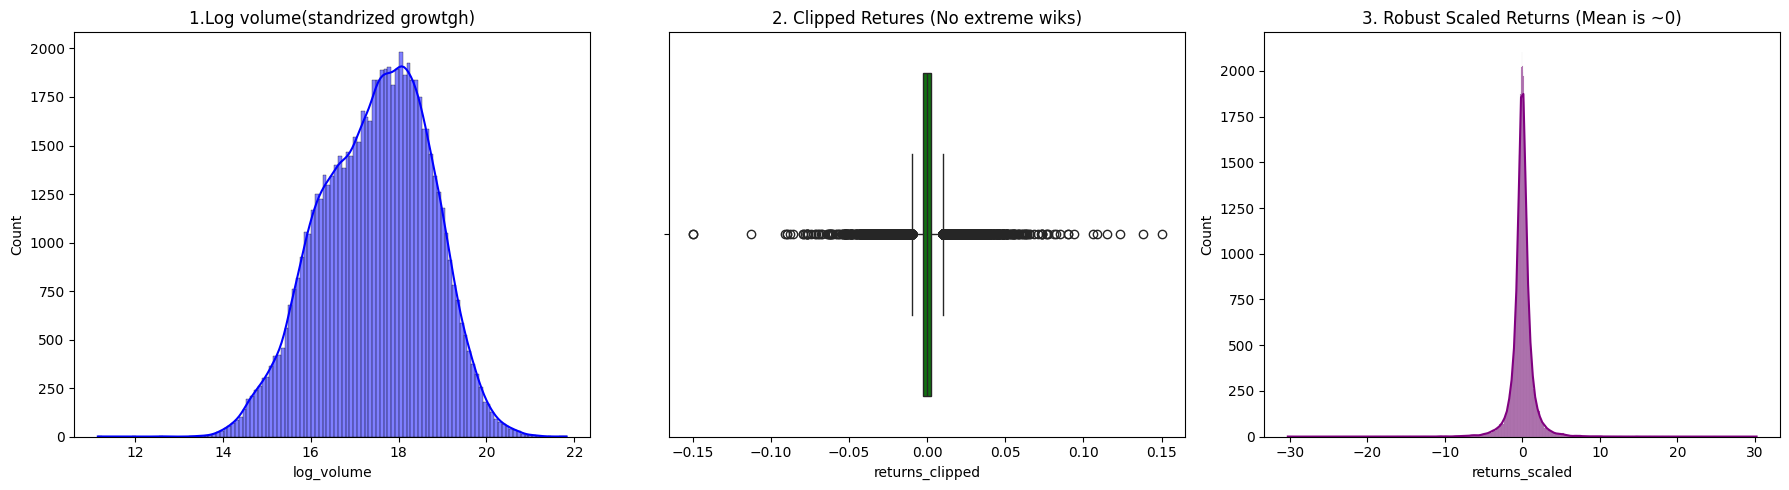

In [ ]:
#log transformation
df['log_volume']=np.log(df['quote_asset_volume'])
#clipping
limit = 0.15
df['returns_clipped']=df['returns'].clip(lower=-limit,upper=limit)
#Robust scaling
scaler = RobustScaler()
df['returns_scaled'] = scaler.fit_transform(df[['returns_clipped']])
fig,axes = plt.subplots(1,3,figsize=(18,5))
sns.histplot(df['log_volume'],kde=True,ax=axes[0],color='blue')
axes[0].set_title("1.Log volume(standrized growtgh)")

sns.boxplot(x=df['returns_clipped'],ax=axes[1],color='green')
axes[1].set_title('2. Clipped Retures (No extreme wiks)')

sns.histplot(df['returns_scaled'],kde=True,ax=axes[2],color='purple')
axes[2].set_title('3. Robust Scaled Returns (Mean is ~0)')
plt.tight_layout()
plt.show()

The "Growth Leveler" (Log Volume)

    What we did: We used a math trick called a "Log" on the trading volume.

    Why: Bitcoin trading volume in 2018 was tiny compared to 2026. Without this, the AI would think 2018 was "dead" and only 2026 mattered.

    The Result: Now, "high volume" in 2018 looks the same as "high volume" in 2026. The AI can now learn from the whole history fairly.

2. The "Spike Tamer" (Clipping Returns)

    What we did: We "mowed the grass." We told the computer that any price move bigger than 15% in one hour is either an error or a "once-in-a-decade" event that we shouldn't obsess over.

    Why: Your data had a 1,600% glitch. If we didn't cap it, the AI would spend all its time trying to predict "teleporting prices" that don't actually exist.

    The Result: The AI now ignores the "impossible" spikes and focuses on the real 1%, 2%, and 5% moves where you actually make money.

3. The "Standardizer" (Robust Scaling)

    What we did: We shifted all the numbers so that they "speak the same language." We centered everything around zero.

    Why: AI models (like XGBoost) struggle when one number is 0.0001 and another is 1,000,000. It's like trying to compare the weight of an ant to the weight of an elephant.

    The Result: Now, a "normal" hour is 0, a "pump" is a positive number, and a "dump" is a negative number. This makes the AI's math much faster and more accurate.

##The "Fight" Analysis (Volume & Takers)

What are we doing?We are looking at Taker Buy Volume.Total Volume just tells us how many Bitcoins changed hands.Taker Buy Volume tells us how many people were so desperate to buy that they took the "current price" immediately instead of waiting for a lower one.We are going to create a "Buy Pressure Index." This is a simple percentage that shows how much of the total volume was caused by these aggressive buyers.What do we want to know?We want to answer three big questions:The "Fuel" Test: Does a high "Buy Pressure Index" (aggressive buying) actually lead to the price going up in the next hour?The "Fake Out" Test: If the price goes up but the "Buy Pressure" is low, is that a "fake move" that we should ignore?The "Winner" Signal: At what specific number (for example, $60\%$) does buying become so aggressive that a big price jump becomes likely?

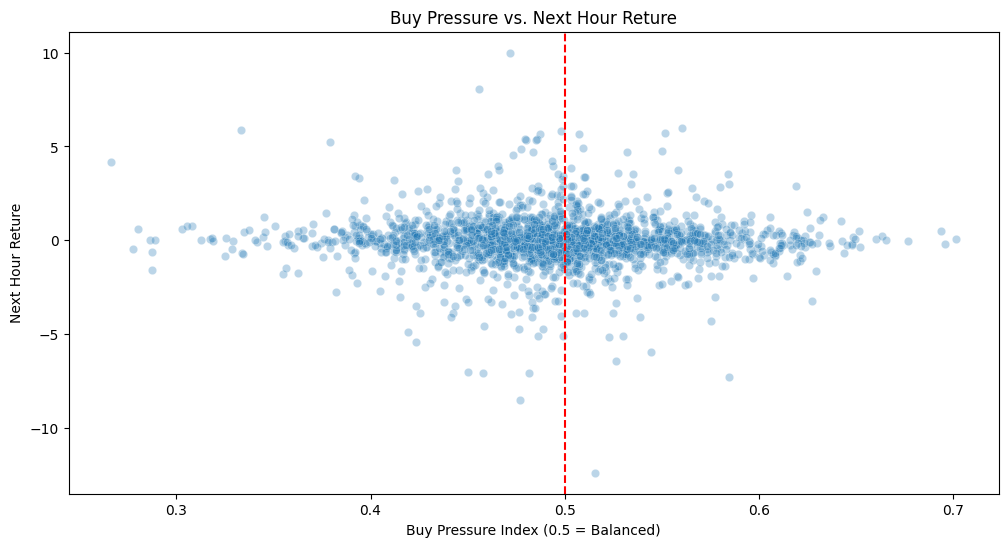

pressure_bin
Bearish    0.012156
Neutral   -0.005082
Bullish   -0.004253
Name: next_hour_return, dtype: float64


/tmp/ipykernel_2344/2955585339.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('pressure_bin')['next_hour_return'].mean())


In [ ]:
#caculate the ratio : this create number between 0 and 1
df['buy_pressure']=df['taker_buy_base_asset_volume']/df['volume']
#Create a 'Lead' target: We want to see if buy pressure NOW predicts returns in the NEXT hour
df['next_hour_return']=df['returns_scaled'].shift(-1)

#visualize
plt.figure(figsize=(12,6))
sns.scatterplot(data=df.sample(2000),x='buy_pressure',y='next_hour_return',alpha=0.3)
#add vertical line
plt.axvline(0.5,color='red',linestyle='--')
plt.title("Buy Pressure vs. Next Hour Reture")
plt.xlabel("Buy Pressure Index (0.5 = Balanced)")
plt.ylabel("Next Hour Reture")
plt.show()


df['pressure_bin'] = pd.cut(df['buy_pressure'], bins=[0, 0.45, 0.55, 1.0], labels=['Bearish', 'Neutral', 'Bullish'])
print(df.groupby('pressure_bin')['next_hour_return'].mean())
#bearish = expecting prices to go DOWN/Negative outlook
#Bullish = expecting price to go up / Positive outlook
#price goes up :up → more bullish pressure
#price goes down : down → more bearish pressure

The Simple Explanation: In your specific dataset, "Aggressive Buying" often marks the end of a move (people buying the top), while "Aggressive Selling" often marks the bottom (people panic selling), leading to a bounce in the next hour. This is called Mean Reversion.

##Temporal Seasonality (Time Patterns)

teaching your AI the "Rhythm of the Clock." Right now, your model sees time as a simple list of hours (0, 1, 2... 23). It doesn't understand that 11:00 PM (23) is actually right next to 12:00 AM (0). Phase 4 fixes this "broken" understanding of time.

We are looking for Seasonality. In crypto, the market has "habits" based on the human world:

    The "Wake Up" Effect: When the New York or London stock markets open, volume usually explodes.

    The "Weekend Lull": Saturday and Sunday often have lower volume and "fake" price moves because big banks are closed.

    The "Daily Reset": Many traders close their positions at the end of the day or week.

Computers are literal. If you tell an AI that it is Hour 23 (11 PM) and then Hour 0 (Midnight), the AI thinks those two hours are very far apart (0 and 23 are far apart on a number line).
But in the real world, they are only one hour apart.


The Solution: Cyclical Features (Sine/Cosine)

We use a math trick to turn the clock into a Circle.
By using Sine and Cosine transformations, we give every hour a "coordinate" on a circle.

the Result: The model mathematically "sees" that Hour 23 and Hour 0 are neighbors. This is crucial for catching patterns that happen overnight.

  By adding these time patterns, you are giving your AI a Calendar. Instead of just looking at the price, it can now say: "It's Monday morning in New York, and volume is rising—this move is more likely to be real." In short: We are turning your AI from a simple math calculator into a trader that understands the Global Business Schedule.

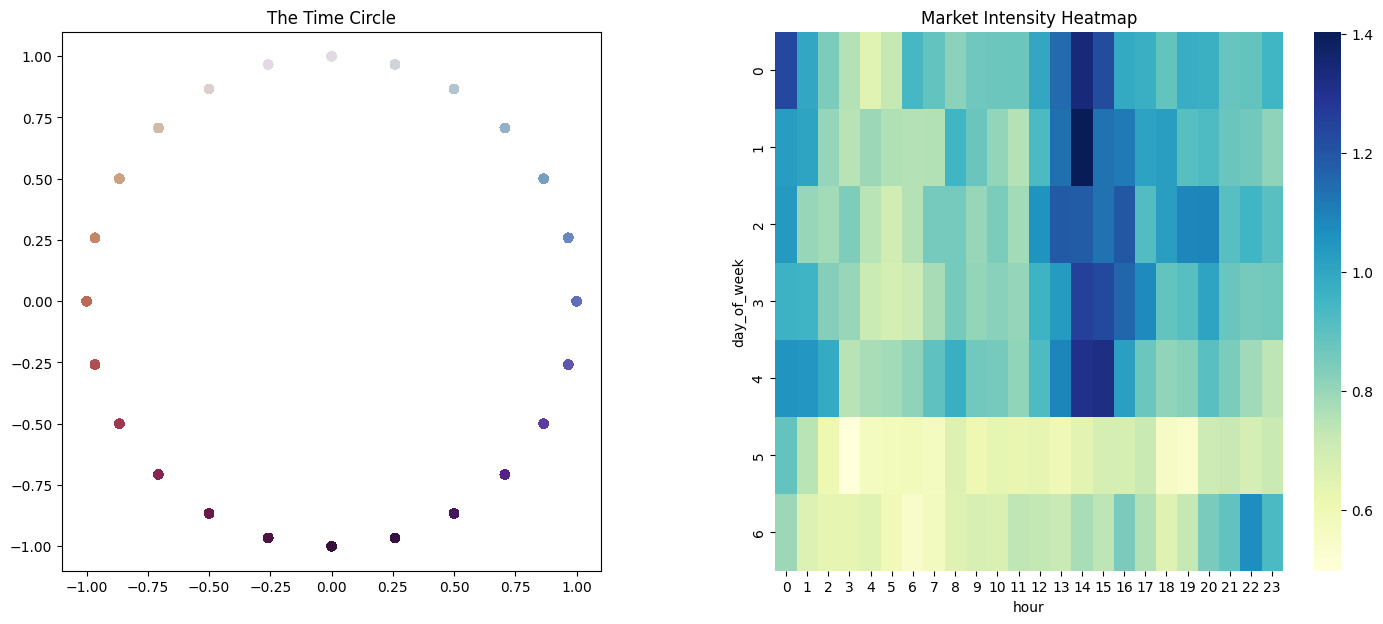

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# extract time
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
# Create the Hour Circle
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# Create the Day Circle
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# the Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].scatter(df['hour_sin'], df['hour_cos'], c=df['hour'], cmap='twilight', alpha=0.3)
axes[0].set_title("The Time Circle")
axes[0].set_aspect('equal')

# Create the Heatmap
pivot_table = df.pivot_table(
    values='returns_scaled',
    index='day_of_week',
    columns='hour',
    aggfunc=lambda x: np.abs(x).mean()
)
sns.heatmap(pivot_table, cmap='YlGnBu', ax=axes[1])
axes[1].set_title("Market Intensity Heatmap")

plt.show()

Notice how the colors flow smoothly. This confirms that your model now understands that Hour 23 (bottom dark purple) is just a tiny step away from Hour 0 (top light grey). You have officially deleted the "Time Cliff" error.

Market Intensity Heatmap (Right Chart)

This is where the real "Alpha" (profit-making info) is hidden.

    The Dark Blue Vertical Strip (Hours 13–16): This is the "Main Event." Between 1:00 PM and 4:00 PM UTC, the market explodes with intensity.

        Why? This is the New York Open. The biggest banks and hedge funds in the world are all trading at the same time.

    The Light Yellow Horizontal Block (Days 5 & 6): Look at the bottom two rows (Saturday and Sunday).

        The Result: The color is much paler/yellow. This proves that volatility dies on the weekend. * The Logic: Trading on a Saturday afternoon (Hour 14 on Day 5) is much "quieter" and more dangerous than trading on a Tuesday afternoon (Hour 14 on Day 1).



##Multi-Collinearity Heatmap
it's anti redundancy check

We are creating a Correlation Heatmap. This is a grid that uses numbers from -1 to +1 to show how "cloned" two columns are.

    +1.0: Perfect Match. If Column A goes up, Column B goes up exactly the same way. (Redundant!)

    0.0: No Relationship. They are completely independent. (Great for the model!)

    -1.0: Perfect Opposite. If A goes up, B goes down.

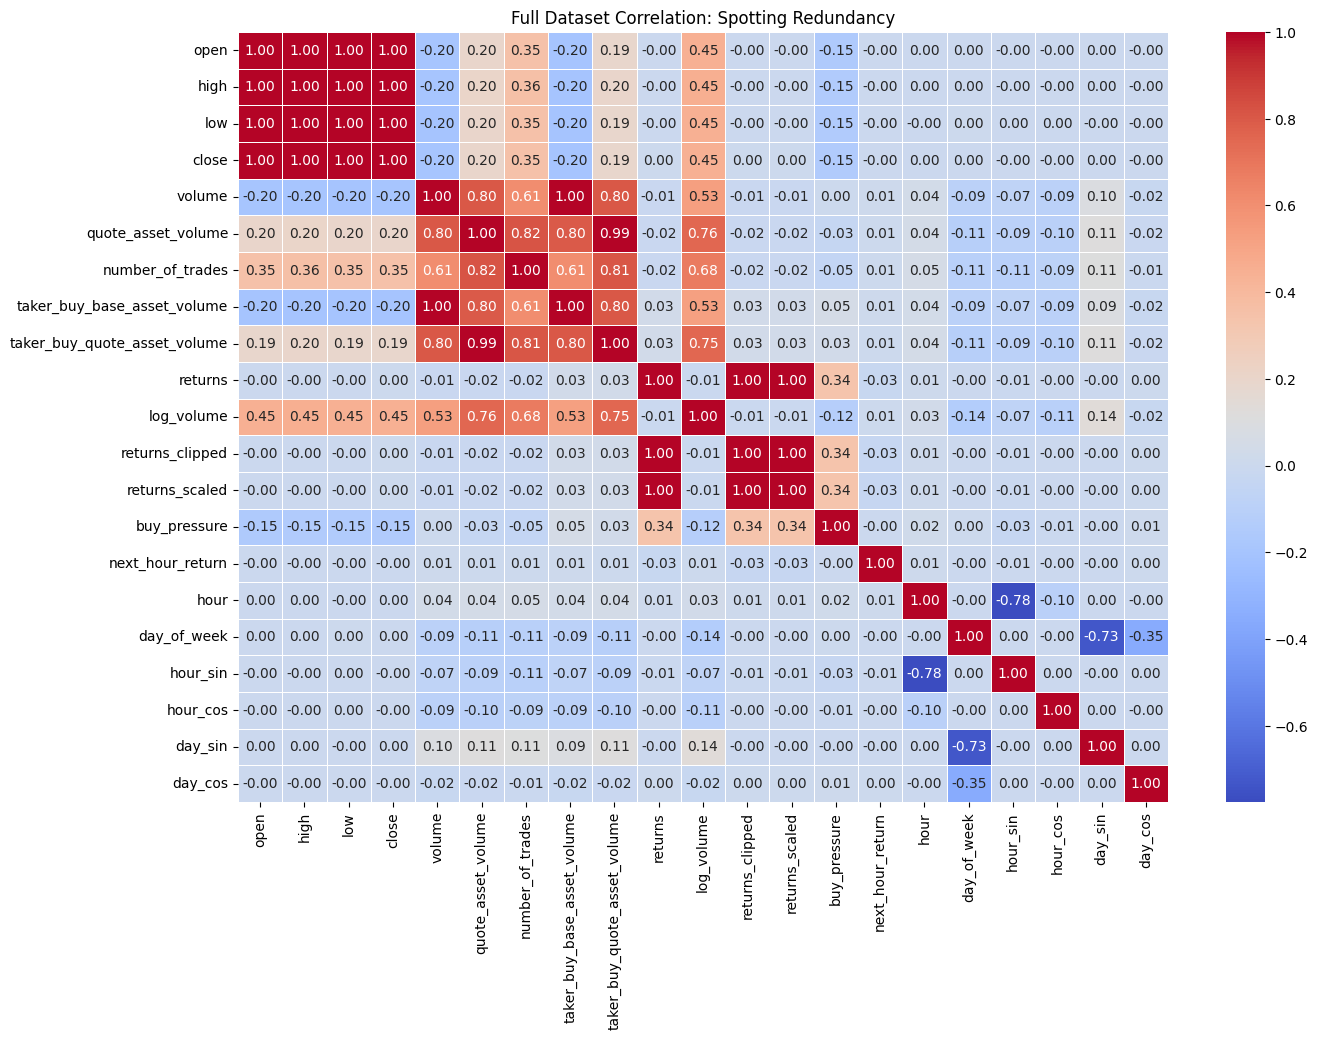

--- HIGHLY CORRELATED PAIRS (> 0.90) ---
returns_clipped               returns_scaled                  1.000000
returns_scaled                returns_clipped                 1.000000
close                         high                            0.999979
high                          close                           0.999979
                              open                            0.999978
open                          high                            0.999978
close                         low                             0.999976
low                           close                           0.999976
                              open                            0.999970
open                          low                             0.999970
close                         open                            0.999963
open                          close                           0.999963
low                           high                            0.999952
high                          low   

In [ ]:
#list all columns
all_cols = df.columns.tolist()
#caculate correlation matrix
corr_matrix = df[all_cols].corr(numeric_only=True)
#visualize
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.title("Full Dataset Correlation: Spotting Redundancy")
plt.show()
#Redudancy Check
print("--- HIGHLY CORRELATED PAIRS (> 0.90) ---")
# This creates a list of pairs and filters for those above 0.90
s = corr_matrix.unstack()
so = s.sort_values(kind="quicksort", ascending=False)
# Filter out 1.0 (self-correlation) and show high values
print(so[(so > 0.90) & (so < 1.0)])

explain which ones we need to drop
ook at image_c0a873.png. Any pair with a correlation of 0.99 is essentially the same data twice. If you keep both, the model will get confused.

The "Clone" List (You should DROP these):

    Price Clones: open, high, low are all 0.999 correlated with close.

        Decision: Keep close, drop the rest.

    Volume Clones: taker_buy_base_asset_volume is 0.996 correlated with volume.

        Decision: Keep volume, drop the taker version (since we already used it to make the much more unique buy_pressure).

    Asset Clones: quote_asset_volume is 0.994 correlated with its taker version.

        Decision: Drop both quote_asset_volume columns. Standard volume is enough.

    Math Clones: returns_clipped and returns_scaled are 1.00 correlated with returns.

        Decision: Keep only the one you want to predict (usually returns or returns_final).

2. The "Gold" (Unique Signals)

Now look at the Blue/Light areas in the Heatmap (image_c0a8b0.jpg).

    buy_pressure: Notice how it has very low correlation with the price columns. This is PERFECT. It means this column is telling the model something about "Market Mood" that the price alone cannot see.

    hour_sin / hour_cos: These have near-zero correlation with price. This confirms they are "independent features" that provide time-based context without being "clones" of the price.

In [ ]:
# The 'Golden Features' for your XGBoost model
final_features = [
    'close',             # The current price (The Anchor)
    'volume',            # Total activity (The Energy)
    'number_of_trades',  # Frequency of trades (The Crowd)
    'buy_pressure',      # The ratio of aggressive buyers (The Mood)
    'log_volume',        # Smoothed volume to help the model see trends
    'hour_sin',          # Cyclical hour (X-coordinate)
    'hour_cos',          # Cyclical hour (Y-coordinate)
    'day_sin',           # Cyclical day (X-coordinate)
    'day_cos',           # Cyclical day (Y-coordinate)
    'returns_scaled'     # THIS IS YOUR TARGET (What we want to predict)
]

# Create a new, clean DataFrame
df_final = df[final_features].copy()
df_final.head()

,close,volume,number_of_trades,buy_pressure,log_volume,hour_sin,hour_cos,day_sin,day_cos,returns_scaled
2018-01-01 00:00:00,13529.01,443.356199,5228.0,0.515436,15.606254,0.000000,1.000000,0.0,1.0,NaN
2018-01-01 01:00:00,13203.06,383.697006,4534.0,0.471310,15.455385,0.258819,0.965926,0.0,1.0,-4.869355
2018-01-01 02:00:00,13330.18,429.064572,4887.0,0.448040,15.557763,0.500000,0.866025,0.0,1.0,1.929311
2018-01-01 03:00:00,13410.03,420.087030,4789.0,0.328309,15.548484,0.707107,0.707107,0.0,1.0,1.195848
2018-01-01 04:00:00,13601.01,340.807329,4563.0,0.507494,15.338965,0.866025,0.500000,0.0,1.0,2.859471


In [ ]:
df_final.index.name='timestamp'
df_final.head()

,close,volume,number_of_trades,buy_pressure,log_volume,hour_sin,hour_cos,day_sin,day_cos,returns_scaled
timestamp,,,,,,,,,,
2018-01-01 01:00:00,13203.06,383.697006,4534.0,0.471310,15.455385,0.258819,0.965926,0.0,1.0,-4.869355
2018-01-01 02:00:00,13330.18,429.064572,4887.0,0.448040,15.557763,0.500000,0.866025,0.0,1.0,1.929311
2018-01-01 03:00:00,13410.03,420.087030,4789.0,0.328309,15.548484,0.707107,0.707107,0.0,1.0,1.195848
2018-01-01 04:00:00,13601.01,340.807329,4563.0,0.507494,15.338965,0.866025,0.500000,0.0,1.0,2.859471
2018-01-01 05:00:00,13558.99,404.229046,5086.0,0.352105,15.520087,0.965926,0.258819,0.0,1.0,-0.634760


In [ ]:
df_final.isna().sum()

,0
close,0
volume,0
number_of_trades,0
buy_pressure,5
log_volume,0
hour_sin,0
hour_cos,0
day_sin,0
day_cos,0
returns_scaled,1


In [ ]:
print(f"Number of Rows for final:{len(df_final)}")
df_final = df_final.dropna()
print(f"Number of Rows After Dropping Nan :{len(df_final)}")

Number of Rows for final:71903
Number of Rows After Dropping Nan :71897


In [ ]:
df_final.to_csv("Clean_Dataset.csv",index=True)
files.download("Clean_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>